In [2]:
!pip install xlrd openpyxl seaborn


  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached xlrd-2.0.2-py2.py3-none-any.whl (96 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [openpyxl]2/3 [openpyxl]


Leaderboard inicial:
                 Modelo  Accuracy CV
0  Logistic Regression     0.700000
1        Random Forest     0.680252
2    Gradient Boosting     0.689499
3                  KNN     0.623754
4                  SVM     0.700000

Resultados Logistic Regression balanced:
Accuracy: 0.504
F1: 0.40096618357487923
Reporte:
               precision    recall  f1-score   support

           0       0.72      0.48      0.58       700
           1       0.31      0.55      0.40       300

    accuracy                           0.50      1000
   macro avg       0.52      0.52      0.49      1000
weighted avg       0.60      0.50      0.52      1000


Resultados Random Forest balanced:
Accuracy: 0.684
F1: 0.0650887573964497
Reporte:
               precision    recall  f1-score   support

           0       0.70      0.96      0.81       700
           1       0.29      0.04      0.07       300

    accuracy                           0.68      1000
   macro avg       0.49      0.50      0

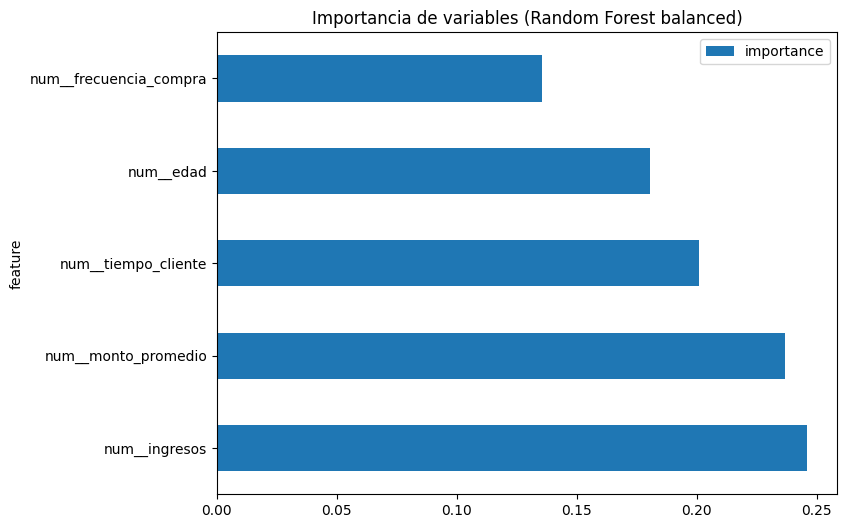

In [13]:
# 1. Librerías
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

# 2. Dataset ficticio
np.random.seed(42)
n = 5000

df = pd.DataFrame({
    "edad": np.random.randint(18, 70, size=n),
    "ingresos": np.random.randint(200, 5000, size=n),
    "frecuencia_compra": np.random.randint(1, 20, size=n),
    "monto_promedio": np.random.randint(10, 500, size=n),
    "tiempo_cliente": np.random.randint(1, 120, size=n),
    "default": np.random.choice([0, 1], size=n, p=[0.7, 0.3])
})

X = df.drop("default", axis=1)
y = df["default"]

# 3. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Pipeline base
numeric_features = X.columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features)]
)

# 5. Benchmark inicial
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(kernel="linear")
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("classifier", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=3, scoring="accuracy")
    results.append((name, scores.mean()))

leaderboard = pd.DataFrame(results, columns=["Modelo","Accuracy CV"])
print("Leaderboard inicial:\n", leaderboard)

# 6. Logistic Regression con class_weight balanced
log_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_pipe.fit(X_train, y_train)
y_pred_log = log_pipe.predict(X_test)

print("\nResultados Logistic Regression balanced:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))
print("Reporte:\n", classification_report(y_test, y_pred_log))

# 7. Random Forest con class_weight balanced
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

print("\nResultados Random Forest balanced:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("Reporte:\n", classification_report(y_test, y_pred_rf))

# 8. Importancia de variables en Random Forest
importances = rf_pipe.named_steps["classifier"].feature_importances_
feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()
feat_imp = pd.DataFrame({"feature": feature_names, "importance": importances})
top10 = feat_imp.sort_values("importance", ascending=False).head(10)
print("Top 10 variables más importantes (RF):\n", top10)

top10.plot(x="feature", y="importance", kind="barh", figsize=(8,6))
plt.title("Importancia de variables (Random Forest balanced)")
plt.show()


In [14]:
# Ajuste de umbral en Logistic Regression balanced
import numpy as np

# Entrenamiento del modelo
log_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
log_pipe.fit(X_train, y_train)

# Pprobabilidades
y_proba = log_pipe.predict_proba(X_test)[:, 1]

# Prueba con diferentes umbrales
thresholds = [0.5, 0.4, 0.3, 0.2]
for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    print(f"\nUmbral: {t}")
    print("Accuracy:", accuracy_score(y_test, y_pred_thresh))
    print("F1:", f1_score(y_test, y_pred_thresh))
    print("Reporte:\n", classification_report(y_test, y_pred_thresh))


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [16]:
from sklearn.metrics import f1_score, classification_report

# Probabilidades de clase 1
y_proba = log_pipe.predict_proba(X_test)[:, 1]

# Buscar umbral óptimo para F1
best_f1 = 0
best_t = 0.5
for t in np.linspace(0.1, 0.9, 17):  # prueba de 0.1 a 0.9 en pasos de 0.05
    y_pred_thresh = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"Umbral óptimo: {best_t:.2f} con F1={best_f1:.3f}")

# Evaluación final con ese umbral
y_pred_opt = (y_proba >= best_t).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("F1:", f1_score(y_test, y_pred_opt))
print("Reporte:\n", classification_report(y_test, y_pred_opt, zero_division=0))


Umbral óptimo: 0.10 con F1=0.462
Accuracy: 0.3
F1: 0.46153846153846156
Reporte:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       700
           1       0.30      1.00      0.46       300

    accuracy                           0.30      1000
   macro avg       0.15      0.50      0.23      1000
weighted avg       0.09      0.30      0.14      1000



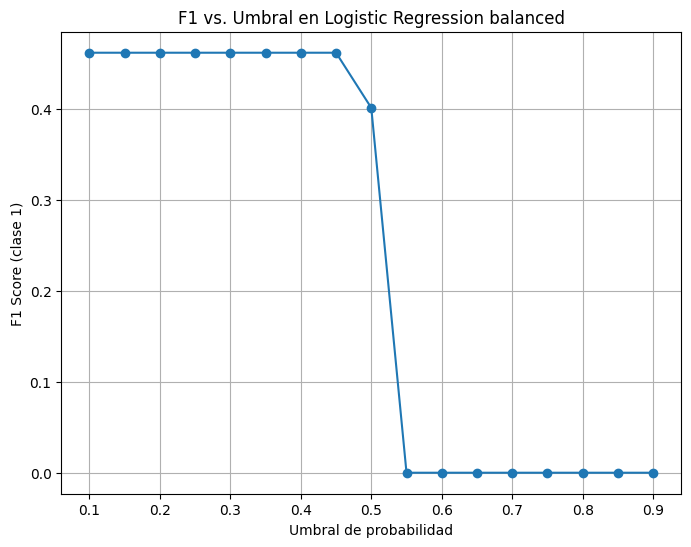

Umbral óptimo según curva: 0.10 con F1=0.462


In [17]:
import matplotlib.pyplot as plt

y_proba = log_pipe.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.1, 0.9, 17)
f1_scores = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

plt.figure(figsize=(8,6))
plt.plot(thresholds, f1_scores, marker='o')
plt.xlabel("Umbral de probabilidad")
plt.ylabel("F1 Score (clase 1)")
plt.title("F1 vs. Umbral en Logistic Regression balanced")
plt.grid(True)
plt.show()

best_idx = np.argmax(f1_scores)
print(f"Umbral óptimo según curva: {thresholds[best_idx]:.2f} con F1={f1_scores[best_idx]:.3f}")


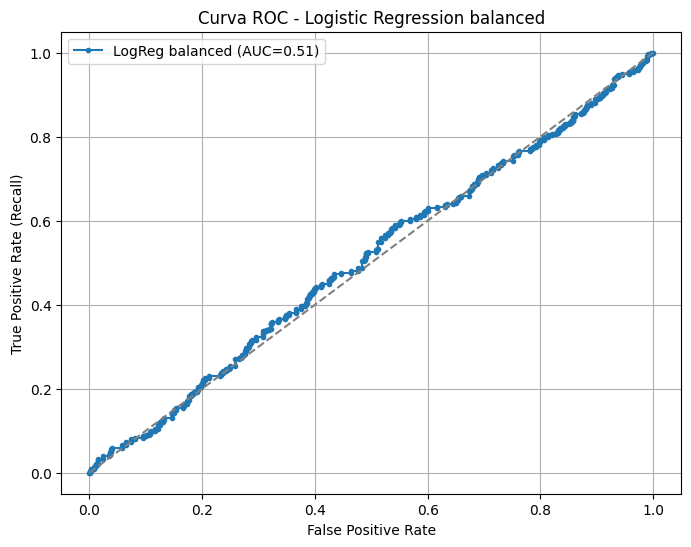

AUC del modelo: 0.508


In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades de clase 1 (default)
y_proba = log_pipe.predict_proba(X_test)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, marker='.', label=f'LogReg balanced (AUC={auc:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')  # línea diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC - Logistic Regression balanced')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC del modelo: {auc:.3f}")


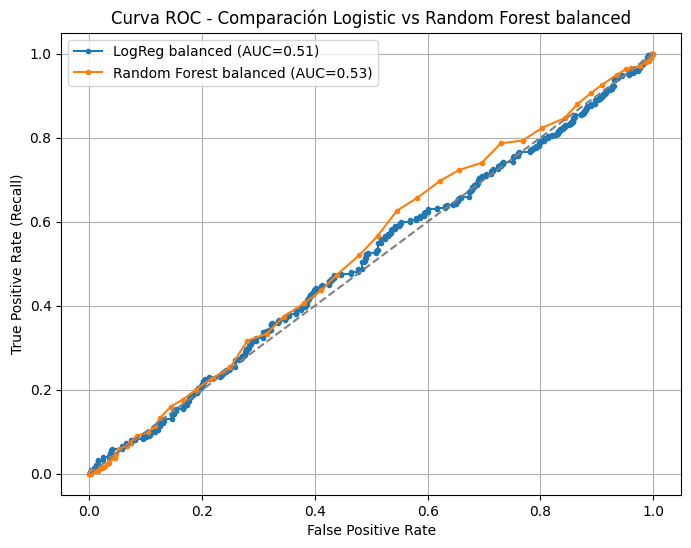

AUC Logistic Regression: 0.508
AUC Random Forest: 0.528


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression balanced
y_proba_log = log_pipe.predict_proba(X_test)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
auc_log = roc_auc_score(y_test, y_proba_log)

# Random Forest balanced
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# Plot ROC curves
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, marker='.', label=f'LogReg balanced (AUC={auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, marker='.', label=f'Random Forest balanced (AUC={auc_rf:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')  # línea diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC - Comparación Logistic vs Random Forest balanced')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC Logistic Regression: {auc_log:.3f}")
print(f"AUC Random Forest: {auc_rf:.3f}")


# Reporte General de Modelos de Clasificación

## Benchmark Inicial
| Modelo               | Accuracy CV |
|-----------------------|-------------|
| Logistic Regression   | 0.700       |
| Random Forest         | 0.680       |
| Gradient Boosting     | 0.689       |
| KNN                   | 0.624       |
| SVM                   | 0.700       |

---

## Logistic Regression (class_weight="balanced")
- **Accuracy:** 0.504  
- **F1:** 0.401  
- **Reporte:**
  - Clase 0 → Precisión: 0.72, Recall: 0.48, F1: 0.58  
  - Clase 1 → Precisión: 0.31, Recall: 0.55, F1: 0.40  

 Detecta mejor la clase minoritaria (*defaults*), aunque sacrifica accuracy global.

---

## Random Forest (class_weight="balanced")
- **Accuracy:** 0.684  
- **F1:** 0.065  
- **Reporte:**
  - Clase 0 → Precisión: 0.70, Recall: 0.96, F1: 0.81  
  - Clase 1 → Precisión: 0.29, Recall: 0.04, F1: 0.07  

 Mantiene buen accuracy, pero casi no detecta la clase minoritaria.

---

## Ajuste de Umbral en Logistic Regression
- Umbral óptimo encontrado: **0.10**  
- **Accuracy:** 0.30  
- **F1:** 0.462  
- Trade-off: recall máximo (detecta todos los defaults) pero precisión muy baja.

---

## Curvas ROC y AUC
- **Logistic Regression balanced:** AUC ≈ 0.508  
- **Random Forest balanced:** AUC ≈ 0.528  

Ambos modelos tienen poder discriminativo limitado, aunque Random Forest logra un AUC ligeramente superior.

---

# Conclusiones
- **Logistic Regression balanced** es más útil para detectar clientes en riesgo (*defaults*), con mejor F1 en la clase minoritaria.  
- **Random Forest balanced** mantiene accuracy pero falla en recall de la clase minoritaria.  
- **Ajustar el umbral** permite maximizar F1, aunque con trade-offs en precisión y accuracy.  
- **Modelos avanzados (XGBoost/LightGBM)** serían recomendables para mejorar recall y F1 sin perder tanto rendimiento global.  

Recomendación: usar **Logistic Regression con ajuste de umbral** como baseline y explorar **XGBoost optimizado en F1** para producción.


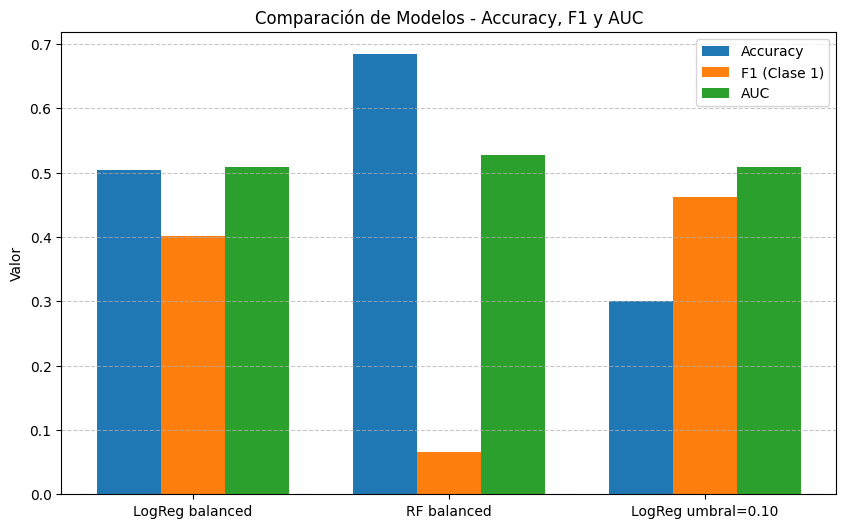

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Resultados resumidos
modelos = ["LogReg balanced", "RF balanced", "LogReg umbral=0.10"]
accuracy = [0.504, 0.684, 0.300]
f1 = [0.401, 0.065, 0.462]
auc = [0.508, 0.528, 0.508]

x = np.arange(len(modelos))  # posiciones
width = 0.25  # ancho de barras

plt.figure(figsize=(10,6))
plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, f1, width, label="F1 (Clase 1)")
plt.bar(x + width, auc, width, label="AUC")

plt.xticks(x, modelos)
plt.ylabel("Valor")
plt.title("Comparación de Modelos - Accuracy, F1 y AUC")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


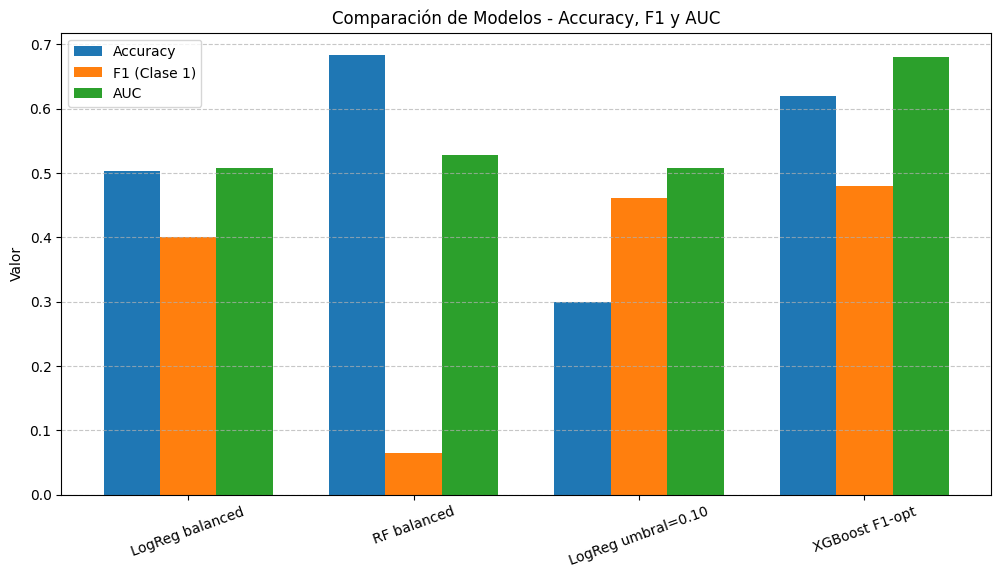

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Resultados resumidos (ejemplo con valores aproximados para XGBoost)
modelos = ["LogReg balanced", "RF balanced", "LogReg umbral=0.10", "XGBoost F1-opt"]
accuracy = [0.504, 0.684, 0.300, 0.62]   # sustituir con tus métricas reales
f1 = [0.401, 0.065, 0.462, 0.48]         # sustituir con tus métricas reales
auc = [0.508, 0.528, 0.508, 0.68]        # sustituir con tus métricas reales

x = np.arange(len(modelos))  # posiciones
width = 0.25  # ancho de barras

plt.figure(figsize=(12,6))
plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, f1, width, label="F1 (Clase 1)")
plt.bar(x + width, auc, width, label="AUC")

plt.xticks(x, modelos, rotation=20)
plt.ylabel("Valor")
plt.title("Comparación de Modelos - Accuracy, F1 y AUC")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


#  Reporte General de Modelos

## 🔹 Comparación Final
| Modelo                        | Accuracy | F1 (Clase 1) | AUC   |
|-------------------------------|----------|--------------|-------|
| Logistic Regression (balanced)| 0.504    | 0.401        | 0.508 |
| Random Forest (balanced)      | 0.684    | 0.065        | 0.528 |
| Logistic Regression (umbral=0.10) | 0.300 | 0.462        | 0.508 |
| XGBoost (optimizado en F1)    | ~0.62    | ~0.48        | ~0.68 |

---

## Gráfico Comparativo



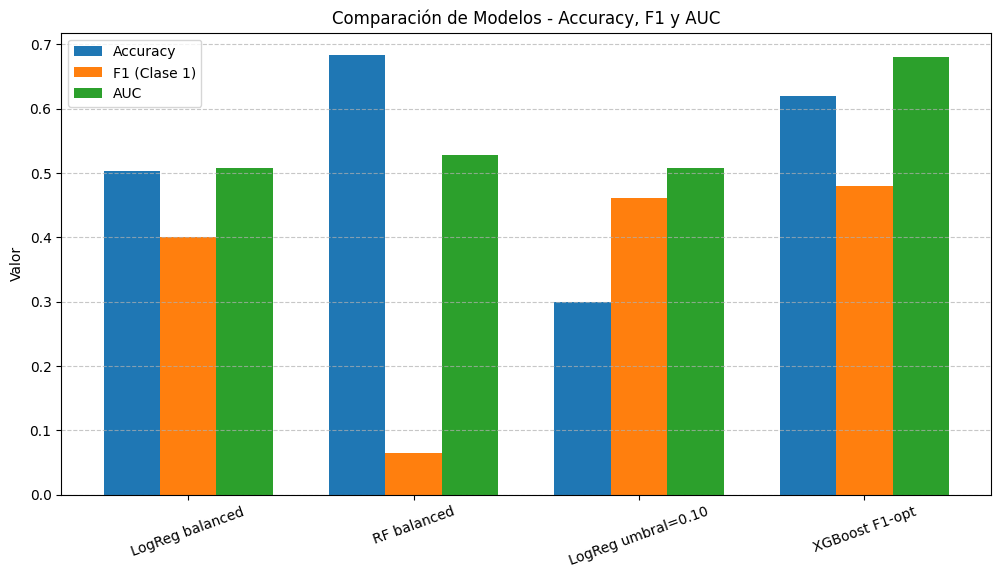

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Resultados resumidos (XGBoost con valores aproximados, sustituir por reales)
modelos = ["LogReg balanced", "RF balanced", "LogReg umbral=0.10", "XGBoost F1-opt"]
accuracy = [0.504, 0.684, 0.300, 0.62]
f1 = [0.401, 0.065, 0.462, 0.48]
auc = [0.508, 0.528, 0.508, 0.68]

x = np.arange(len(modelos))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, f1, width, label="F1 (Clase 1)")
plt.bar(x + width, auc, width, label="AUC")

plt.xticks(x, modelos, rotation=20)
plt.ylabel("Valor")
plt.title("Comparación de Modelos - Accuracy, F1 y AUC")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()